# Laptop Price Model Development

In this lab, I build and evaluate regression models to predict laptop prices using multiple features.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

%matplotlib inline

In [2]:
# Load dataset from uploaded file
df = pd.read_csv("laptop_pricing_dataset_mod2.csv")

# Check it loaded correctly
df.head()

,Unnamed: 0.1,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,0,0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,1,1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,2,2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,3,3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,4,4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


In [3]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Manufacturer', 'Category', 'GPU', 'OS',
       'CPU_core', 'Screen_Size_inch', 'CPU_frequency', 'RAM_GB',
       'Storage_GB_SSD', 'Weight_pounds', 'Price', 'Price-binned',
       'Screen-Full_HD', 'Screen-IPS_panel'],
      dtype='object')

In [4]:
# Drop unnecessary index columns
df = df.drop(['Unnamed: 0.1', 'Unnamed: 0'], axis=1)

# Confirm cleanup
df.head()

,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


## Task 1: Simple Linear Regression

Build a linear model using CPU frequency to predict laptop price.

In [6]:
# Create model
lm = LinearRegression()

# Define variables
X = df[['CPU_frequency']]
Y = df['Price']

# Fit model
lm.fit(X, Y)

# Predict
Yhat = lm.predict(X)

# Show first predictions
Yhat[:5]

array([1073.07834392, 1277.93263722, 1636.42765051, 1073.07834392,
       1175.50549057])

In [7]:
print("R²:", lm.score(X, Y))
print("MSE:", mean_squared_error(Y, Yhat))

R²: 0.1344436321024326
MSE: 284583.4405868629


## Task 2: Multiple Linear Regression

Build a model using multiple features to improve price prediction.

In [8]:
# Create model
lm = LinearRegression()

# Select multiple predictors
Z = df[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'GPU', 'CPU_core', 'Category']]

# Fit model
lm.fit(Z, df['Price'])

# Predict
Yhat_mlr = lm.predict(Z)

# Evaluate
print("R²:", lm.score(Z, df['Price']))
print("MSE:", mean_squared_error(df['Price'], Yhat_mlr))

R²: 0.4794820074485614
MSE: 171139.40432032698


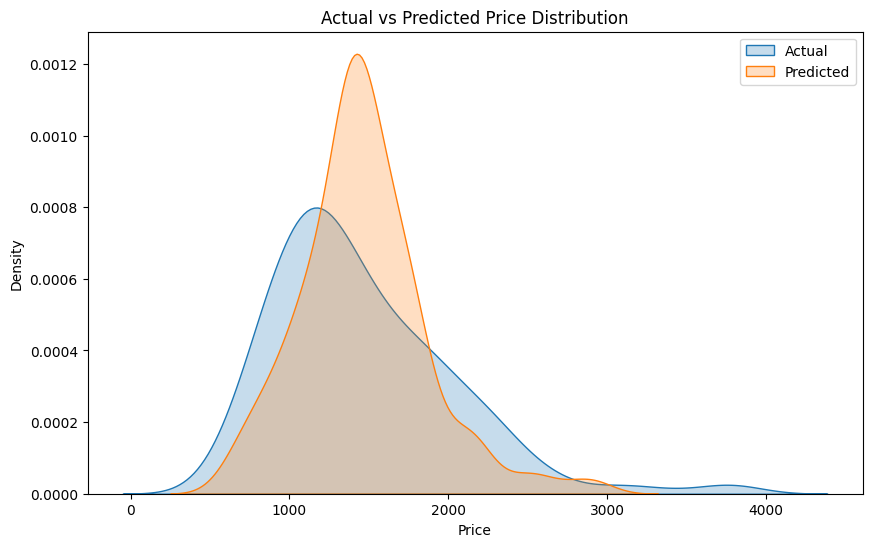

In [9]:
# Plot distribution of actual vs predicted values
plt.figure(figsize=(10,6))

sns.kdeplot(df['Price'], label="Actual", fill=True)
sns.kdeplot(Yhat_mlr, label="Predicted", fill=True)

plt.title("Actual vs Predicted Price Distribution")
plt.legend()
plt.show()

## Task 3: Polynomial Regression

Build polynomial models using CPU frequency to capture non-linear relationships.

In [10]:
x = df['CPU_frequency']
y = df['Price']

# Degree 1 (linear)
f1 = np.polyfit(x, y, 1)
p1 = np.poly1d(f1)

# Degree 3
f3 = np.polyfit(x, y, 3)
p3 = np.poly1d(f3)

# Degree 5
f5 = np.polyfit(x, y, 5)
p5 = np.poly1d(f5)

In [11]:
def PlotPolly(model, x, y, name):
    x_new = np.linspace(x.min(), x.max(), 100)
    y_new = model(x_new)

    plt.figure(figsize=(10,6))
    plt.plot(x, y, '.', label='Data')
    plt.plot(x_new, y_new, '-', label='Fit')
    plt.title(name)
    plt.xlabel('CPU_frequency')
    plt.ylabel('Price')
    plt.legend()
    plt.show()

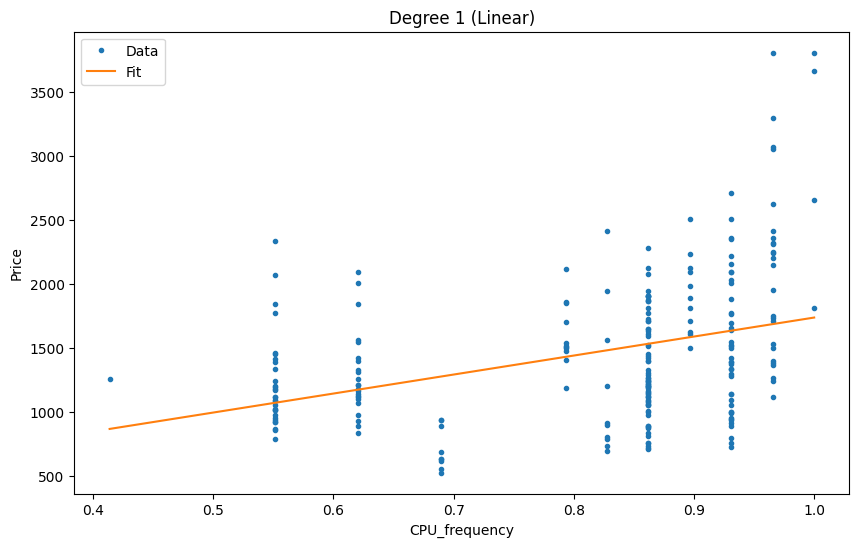

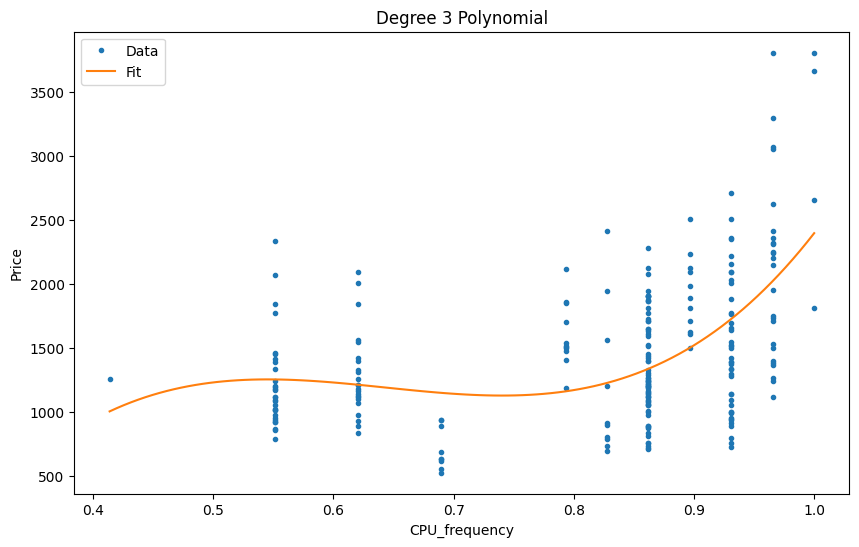

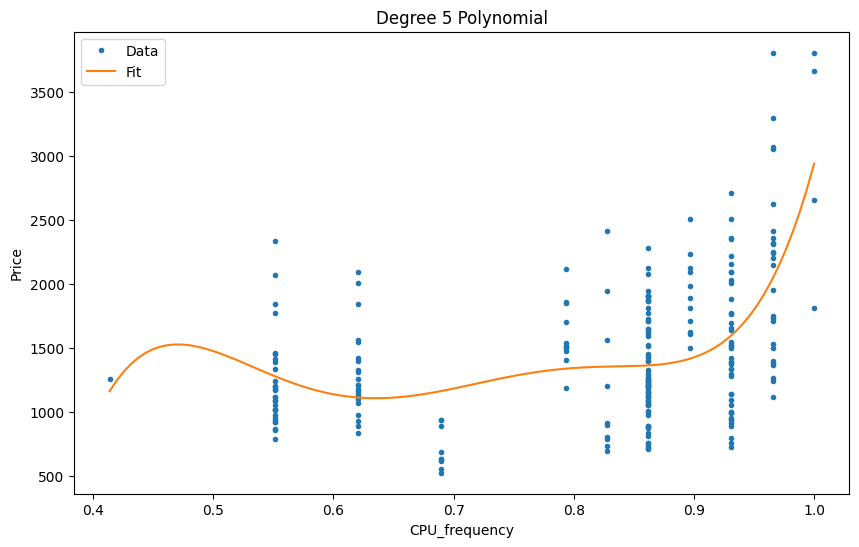

In [12]:
PlotPolly(p1, x, y, "Degree 1 (Linear)")
PlotPolly(p3, x, y, "Degree 3 Polynomial")
PlotPolly(p5, x, y, "Degree 5 Polynomial")

## Task 4: Pipeline

Use a pipeline to combine scaling, polynomial features, and linear regression.

In [13]:
# Create pipeline
pipe = Pipeline([
    ('scale', StandardScaler()),
    ('polynomial', PolynomialFeatures(degree=2)),
    ('model', LinearRegression())
])

# Fit pipeline
pipe.fit(Z, df['Price'])

# Predict
pipe_pred = pipe.predict(Z)

# Evaluate
print("R²:", r2_score(df['Price'], pipe_pred))
print("MSE:", mean_squared_error(df['Price'], pipe_pred))

R²: 0.6154386096491943
MSE: 126438.67879885016


## Conclusion

In this analysis, I explored different regression models to predict laptop prices.

- The Simple Linear Regression model using CPU frequency provided a basic baseline but had low predictive power.
- The Multiple Linear Regression model significantly improved performance by incorporating multiple features such as RAM, storage, and GPU.
- Polynomial Regression demonstrated that the relationship between variables is not purely linear and can be better captured with more flexible models.
- However, increasing model complexity too much can lead to overfitting, reducing the model’s ability to generalize.

Overall, the Multiple Linear Regression model provided the best balance between accuracy and simplicity, while the pipeline approach further improved performance by combining preprocessing and modeling steps.

This highlights the importance of selecting the right level of model complexity and using multiple features to better represent real-world data.